# Ejercicio 2


In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

## Parte 1

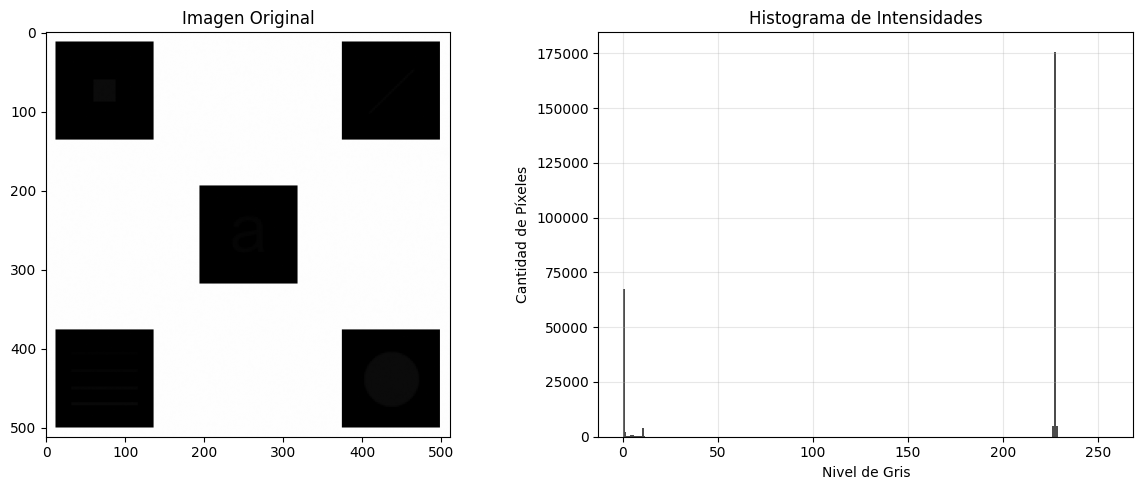

In [3]:
img = cv2.imread("../Imagenes_cursado/cuadros.tif", cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title('Imagen Original')
 


plt.subplot(1, 2, 2)
plt.hist(img.ravel(), bins=256, range=[0, 256], color='black', alpha=0.7)
plt.title('Histograma de Intensidades')
plt.xlabel('Nivel de Gris')
plt.ylabel('Cantidad de Píxeles')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Vamos a analizar los perfiles
- HOrizontales: 100, 250, 400
- Verticales: 100, 250, 400
para encontrar las pocisiones donde arrancan y terminan los cuadrados

In [8]:
# promedio por filas
perfil_horizontal = np.min(img, axis=1)
perfil_vertical   = np.min(img, axis=0)

th_h = np.mean(perfil_horizontal) - 25
th_v = np.mean(perfil_vertical) - 25

filas_oscuras = np.where(perfil_horizontal < th_h)[0]
cols_oscuras  = np.where(perfil_vertical < th_v)[0]

print(filas_oscuras)
print(cols_oscuras)

[ 12  13  14  15  16  17  18  19  20  21  22  23  24  25  26  27  28  29
  30  31  32  33  34  35  36  37  38  39  40  41  42  43  44  45  46  47
  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65
  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83
  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101
 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119
 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 194 195
 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213
 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231
 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249
 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265 266 267
 268 269 270 271 272 273 274 275 276 277 278 279 280 281 282 283 284 285
 286 287 288 289 290 291 292 293 294 295 296 297 298 299 300 301 302 303
 304 305 306 307 308 309 310 311 312 313 314 315 31

In [9]:
#identificamos los patrones sucesivos

def agrupar_indices(indices):

    grupos = []
    inicio = indices[0]
    anterior = indices[0]

    for i in indices[1:]:
        if i != anterior + 1:
            grupos.append((inicio, anterior))
            inicio = i
        anterior = i

    grupos.append((inicio, anterior))
    return grupos

grupos_h = agrupar_indices(filas_oscuras)
grupos_v = agrupar_indices(cols_oscuras)

print(grupos_h)
print(grupos_v)

[(np.int64(12), np.int64(135)), (np.int64(194), np.int64(317)), (np.int64(376), np.int64(499))]
[(np.int64(12), np.int64(135)), (np.int64(194), np.int64(317)), (np.int64(374), np.int64(497))]


tenemos los extermos pero 

In [18]:
rois = [
    (12, 12, 135, 135),
    (374, 12, 497, 135),
    (194, 194, 317, 317),
    (12, 376, 135, 499),
    (374, 376, 497, 499),
]

global_eq = cv2.equalizeHist(img)

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(2,2)
)


local_eq = img.copy()
for (x1, y1, x2, y2) in rois:
    roi = img[y1:y2, x1:x2]
    roi_eq =clahe.apply(roi)
    local_eq[y1:y2, x1:x2] = roi_eq

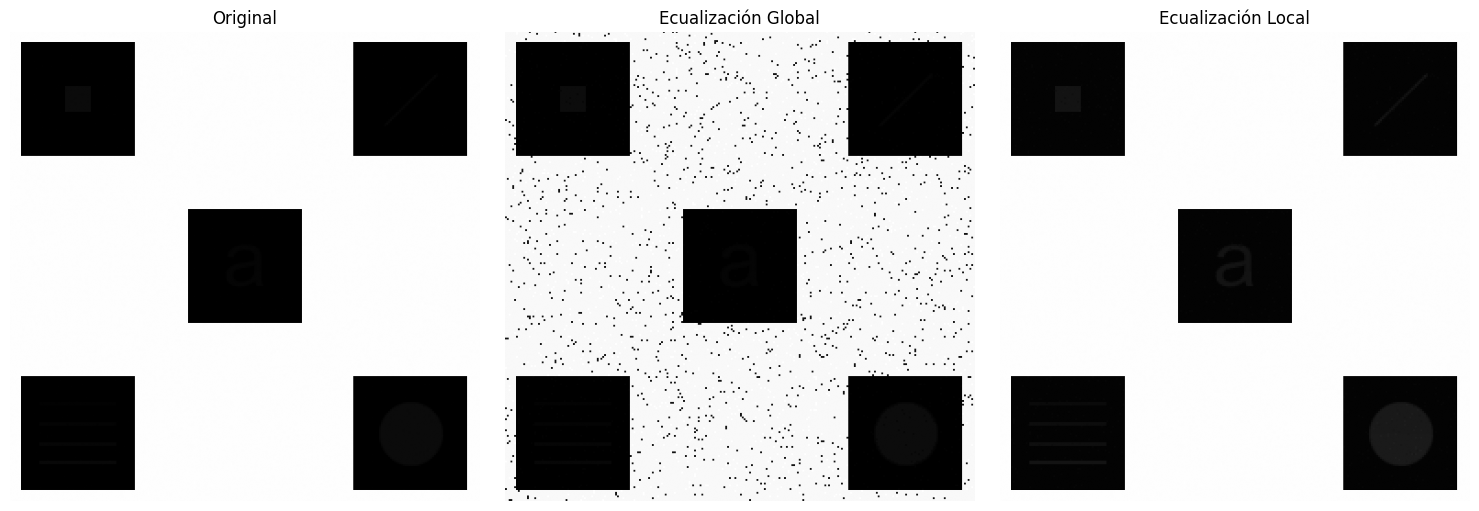

In [19]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(global_eq, cmap='gray')
plt.title("Ecualización Global")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(local_eq, cmap='gray')
plt.title("Ecualización Local")
plt.axis("off")

plt.tight_layout()
plt.show()


## Parte
Busqueda de objeto por correlacion

In [22]:
templates = []
labels = []

categorias = [
    "Bandera",
    "Caricaturas",
    "Paisaje",
    "Personaje"
]

for categoria in categorias:
    for i in range(1,6):
        path = f"../Imagenes_cursado/{categoria}{i:02d}.jpg"
        img = cv2.imread(
            path,
            cv2.IMREAD_GRAYSCALE
        )
        templates.append(img)

        labels.append(categoria)

In [23]:
for idx, (x1, y1, x2, y2) in enumerate(rois): #recorremos todas las regiones
    roi = local_eq[y1:y2, x1:x2] #la extraemos
    mejor_score = -1
    mejor_label = None

    for template, label in zip(templates, labels): #buscamos en esa region toda la plantilla
        # mismo tamaño
        template_resize = cv2.resize(
            template,
            (roi.shape[1], roi.shape[0])
        )

        resultado = cv2.matchTemplate(
            roi,
            template_resize,
            cv2.TM_CCORR_NORMED
        ) #corelacion

        _, max_val, _, _ = cv2.minMaxLoc(resultado) #nos quedamos con el maximo, no nos interesa en que posicion

        if max_val > mejor_score:

            mejor_score = max_val
            mejor_label = label

    print(f"ROI {idx+1}")
    print("Clase:", mejor_label)
    print("Score:", mejor_score)
    print()
    

ROI 1
Clase: Bandera
Score: 0.7809243202209473

ROI 2
Clase: Paisaje
Score: 0.8864541053771973

ROI 3
Clase: Bandera
Score: 0.7987570762634277

ROI 4
Clase: Paisaje
Score: 0.7909841537475586

ROI 5
Clase: Personaje
Score: 0.776654064655304

